In [55]:
import numpy as np
import pandas as pd
from scipy.optimize import curve_fit
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt

def hill_function(x, A, C, D):
    return A*x**C / (D**C + x**C) 

### Carga de datos y selección de variables 

In [56]:
### Cargar el DF completo 
df = pd.read_excel('./input.xlsx')

### Filtro de entrenamiento (opcional, si no hay que filtrar para calibrar la curva se puede usar una copia del frame original)
df_training = df.copy()
# df_training = df[df['Fecha']>='01-01-2024'].copy()

### Definir las variables independientes y dependientes 
x_var = 'NPS_Prepago'
y_var = 'NPS_Prepago_contribt'

### Modelado

In [87]:
### Preparación de los datos para el modelado 

X_data = df_training[x_var].to_numpy()
Y_data = df_training[y_var].to_numpy()

bounds = ([Y_data.max()*0.9,1,X_data.min()],
          [np.inf,2,X_data.max()])

### Optimización de la curva 
params, _ = curve_fit(hill_function, X_data, Y_data, bounds=bounds, method='trf')

In [ ]:
### Parametros optimizados (A, C, D)
df_params = pd.DataFrame(data=params)
df_params.index = ['A','C','D']
df_params.to_clipboard() ### PEGA EN EXCEL! ;)
df_params

,0
A,116243.076308
C,1.677797
D,0.520000


### Validación de modelo

#### Training

In [59]:
# Training Fit
r2_score(df_training[y_var], hill_function(df_training[x_var], *params))

0.8720165029247334

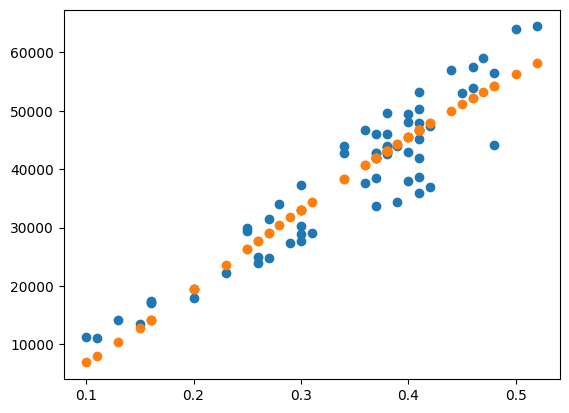

In [60]:
# Full fit scatter
plt.scatter(df_training[x_var], df_training[y_var])
plt.scatter(df_training[x_var], hill_function(df_training[x_var], *params))

#### Full DF

In [61]:
# Full fit
r2_score(df[y_var], hill_function(df[x_var], *params))

0.8720165029247334

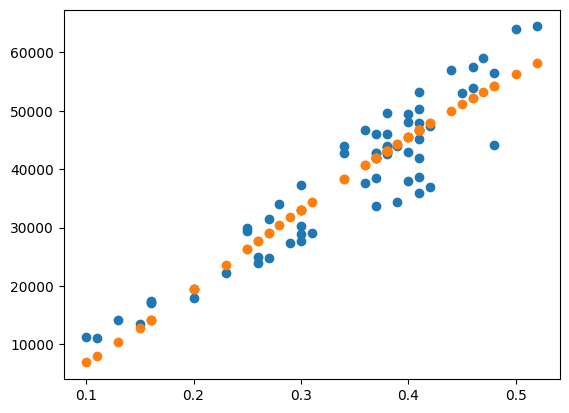

In [62]:
# Full fit scatter 
plt.scatter(df[x_var], df[y_var])
plt.scatter(df[x_var], hill_function(df[x_var], *params))

### Generador de series

In [ ]:
series_x_val = np.arange(0,0.6001,0.001)
series_y_val = hill_function(series_x_val, *params)

df_series = pd.DataFrame({
    'x_var': series_x_val,
    'y_var':series_y_val
})

df_series.to_clipboard() ### PEGA EN EXCEL! ;)

df_series

,x_var,y_var
0,0.000,0.000000
1,0.001,3.224436
2,0.002,10.315598
3,0.003,20.365833
4,0.004,32.997175
...,...,...
596,0.596,64743.833391
597,0.597,64824.499528
598,0.598,64905.004562
599,0.599,64985.348772
